# Import Libraries we need

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import missingno as msno
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import classification_report, accuracy_score, f1_score,confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb
from category_encoders import TargetEncoder

# **Read Train Data**

In [3]:
df = pd.read_csv('Train.csv')
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [4]:
print("Dataset Shape:", df.shape)
print(df.info())

Dataset Shape: (22792, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22792 entries, 0 to 22791
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             22792 non-null  int64 
 1   work-class      22792 non-null  object
 2   work-fnl        22792 non-null  int64 
 3   education       22792 non-null  object
 4   education-num   22792 non-null  int64 
 5   marital-status  22792 non-null  object
 6   position        22792 non-null  object
 7   relationship    22792 non-null  object
 8   race            22792 non-null  object
 9   sex             22792 non-null  object
 10  capital-gain    22792 non-null  int64 
 11  capital-loss    22792 non-null  int64 
 12  hours-per-week  22792 non-null  int64 
 13  native-country  22792 non-null  object
 14  salary          22792 non-null  object
dtypes: int64(6), object(9)
memory usage: 2.6+ MB
None


In [5]:
print(df.describe())  # for numerical features

                age      work-fnl  education-num  capital-gain  capital-loss  \
count  22792.000000  2.279200e+04   22792.000000  22792.000000  22792.000000   
mean      38.593542  1.896337e+05      10.084065   1061.232757     86.730037   
std       13.657228  1.049660e+05       2.556860   7342.691929    400.970842   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.183760e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783840e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.367890e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    22792.000000  
mean        40.409705  
std         12.283072  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [6]:
print(df.describe(include=['object'])) # for categorical features

       work-class education      marital-status        position relationship  \
count       22792     22792               22792           22792        22792   
unique          9        16                   7              15            6   
top       Private   HS-grad  Married-civ-spouse  Prof-specialty      Husband   
freq        15842      7422               10440            2905         9166   

         race    sex native-country salary  
count   22792  22792          22792  22792  
unique      5      2             42      2  
top     White   Male  United-States  <=50K  
freq    19493  15249          20415  17355  


In [7]:
for col in df.select_dtypes(include=['O', 'object']).columns:
    unique_vals = df[col].unique()
    print(f"{col}: {unique_vals[:10]}... (Total: {len(unique_vals)})")
    if '?' in unique_vals:
        print(f"  Found '?' in {col}: {df[df[col] == '?'].shape[0]} occurrences")

work-class: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' '?'
 'Self-emp-inc' 'Without-pay' 'Never-worked']... (Total: 9)
  Found '?' in work-class: 1275 occurrences
education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate']... (Total: 16)
marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']... (Total: 7)
position: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct']... (Total: 15)
  Found '?' in position: 1279 occurrences
relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']... (Total: 6)
race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']... (Total: 5)
sex: ['Male' 'Female']... (Total: 2)
native-country: ['United-States' 'Cuba' 'Jamaica' 'India' '?' '

#### the dataset is unbalanced

In [8]:
print("\nTarget Variable (salary) Distribution:")
print(df['salary'].value_counts(normalize=True))


Target Variable (salary) Distribution:
salary
<=50K    0.761451
>50K     0.238549
Name: proportion, dtype: float64


# **Visualization**

Text(0.5, 1.0, 'Distribution of Salary')

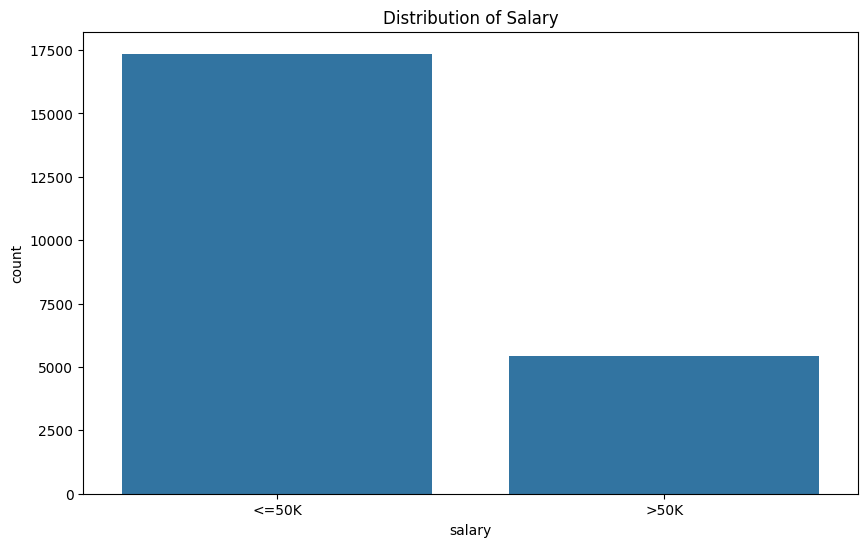

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(x='salary', data=df)
plt.title('Distribution of Salary')
#plt.savefig('salary_dist.png')

#### numeric features vs target

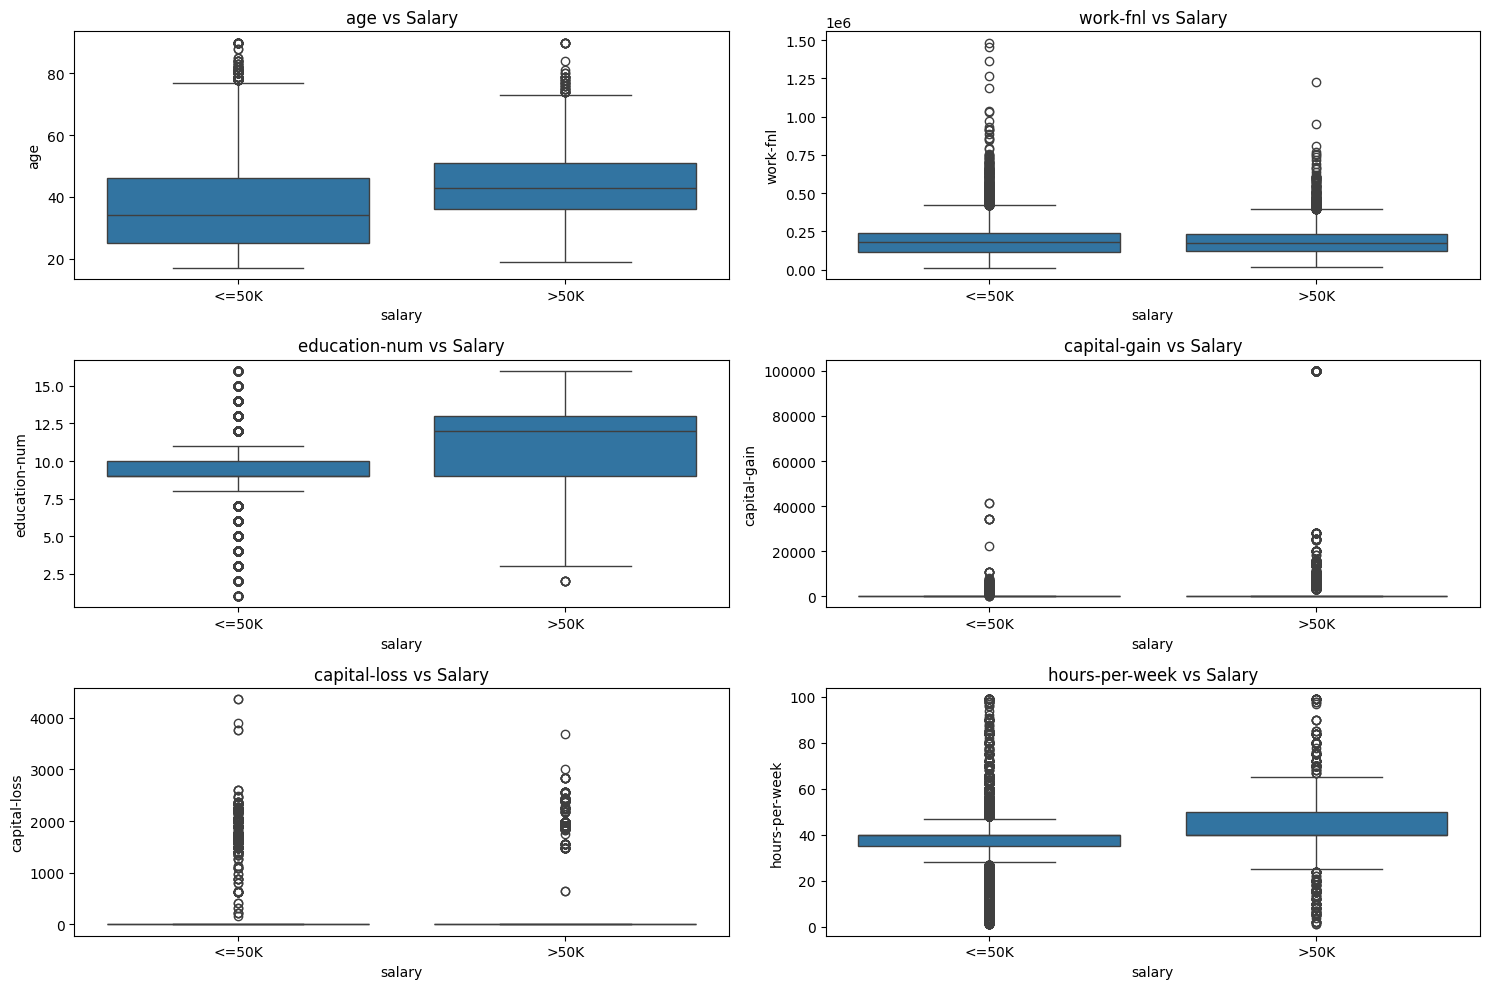

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x='salary', y=col, data=df)
    plt.title(f'{col} vs Salary')
plt.tight_layout()
#plt.savefig('numeric_vs_salary.png')
plt.show()

#### categorical features vs target

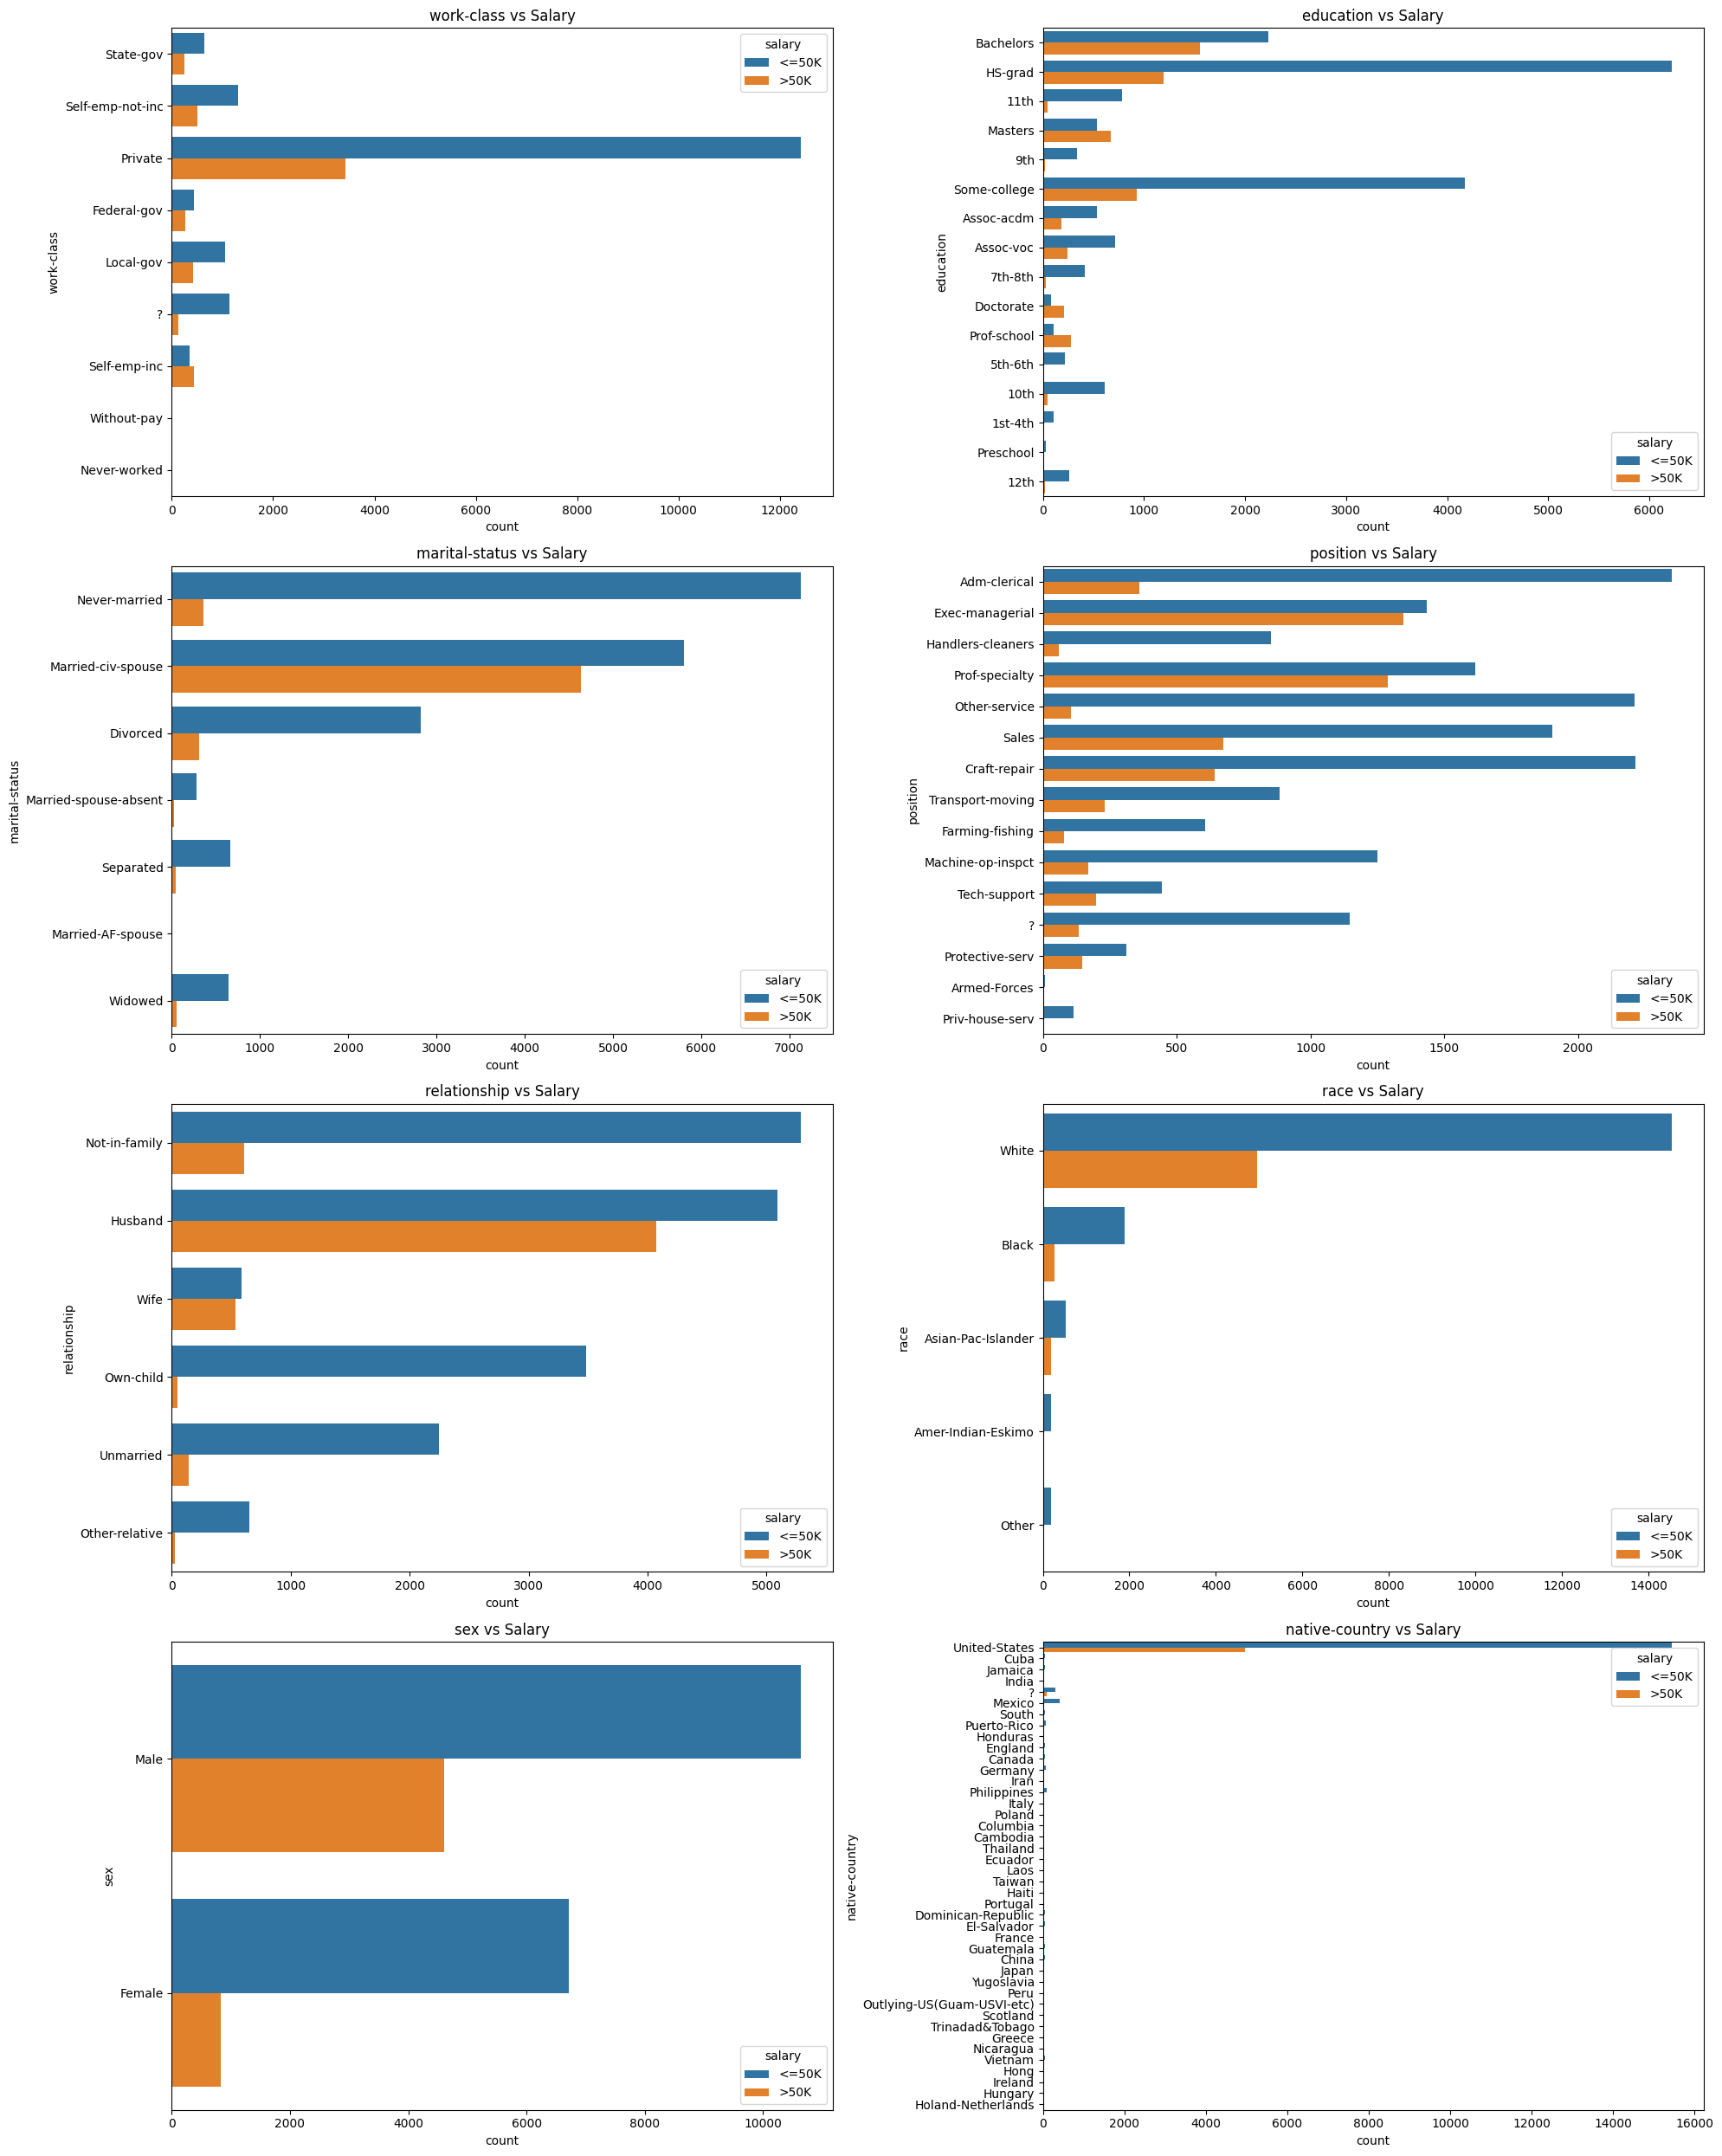

In [11]:

categorical_cols = ['work-class', 'education', 'marital-status', 'position', 'relationship', 'race', 'sex','native-country']
plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 2, i)
    sns.countplot(y=col, hue='salary', data=df)
    plt.title(f'{col} vs Salary')
plt.tight_layout()
#plt.savefig('categorical_vs_salary.png')



# **Preprocessing**

In [12]:
print(df.duplicated().sum())
df=df.drop_duplicates()
print(df.describe())

15
                age      work-fnl  education-num  capital-gain  capital-loss  \
count  22777.000000  2.277700e+04   22777.000000  22777.000000  22777.000000   
mean      38.596918  1.896490e+05      10.085349   1061.931642     86.787154   
std       13.652581  1.049714e+05       2.555376   7345.058911    401.096678   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.183760e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.784170e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.367840e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    22777.000000  
mean        40.413926  
std         12.281707  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


# Handling missing values

In [13]:
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)
df=df.dropna()

<Axes: >

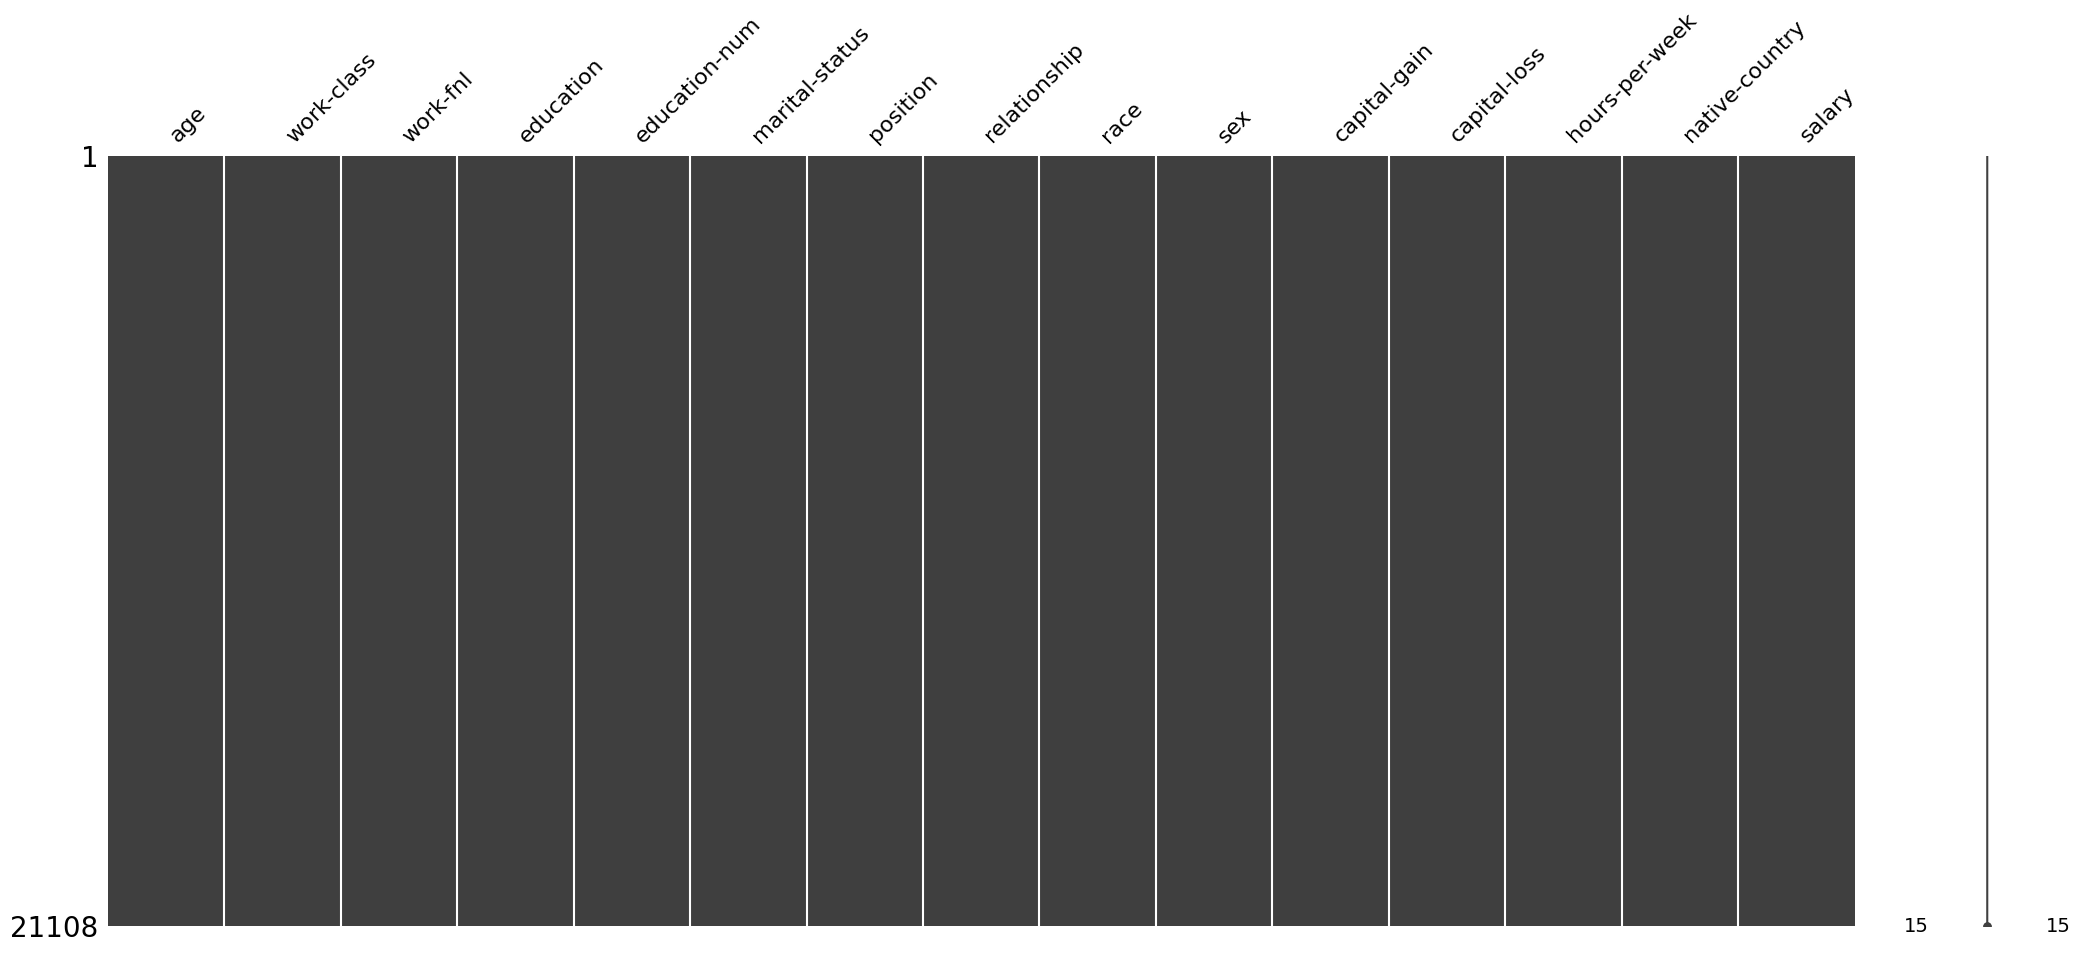

In [14]:
msno.matrix(df)

In [15]:
'''
from sklearn.ensemble import RandomForestClassifier

def fill_missing_values(df_in, target_col, drop_cols=None, n_estimators=200, random_state=42, model=None):
    df_work = df_in.copy()
    df_work = df_work.replace(r'^\s*\?\s*$', np.nan, regex=True)


    if drop_cols is None:
        drop_cols = ['salary']

    exclude_set = set(drop_cols + [target_col])
    feature_cols = [c for c in df_work.columns if c not in exclude_set]

    X_all = pd.get_dummies(df_work[feature_cols], dummy_na=True)

    train_mask = df_work[target_col].notna()
    pred_mask = df_work[target_col].isna()

    if pred_mask.sum() == 0:
        return df_work, model

    if model is None:
        mX_train = X_all.loc[train_mask]
        my_train = df_work.loc[train_mask, target_col]

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            random_state=random_state,
            n_jobs=-1,
            class_weight='balanced_subsample'
        )
        model.fit(mX_train, my_train)
    else :
      X_all = X_all.reindex(columns=model.feature_names_in_, fill_value=0)


    mX_pred = X_all.loc[pred_mask]
    my_pred = model.predict(mX_pred)
    df_work.loc[pred_mask, target_col] = my_pred

    return df_work, model
'''
#df, model_workclass = fill_missing_values(df, target_col='work-class', drop_cols=['salary', 'position'])
#df, model_position = fill_missing_values(df, target_col='position', drop_cols=['salary'])

#joblib.dump(model_workclass, 'model_workclass.joblib')
#joblib.dump(model_position, 'model_position.joblib')

"\nfrom sklearn.ensemble import RandomForestClassifier\n\ndef fill_missing_values(df_in, target_col, drop_cols=None, n_estimators=200, random_state=42, model=None):\n    df_work = df_in.copy()\n    df_work = df_work.replace(r'^\\s*\\?\\s*$', np.nan, regex=True)\n\n\n    if drop_cols is None:\n        drop_cols = ['salary']\n\n    exclude_set = set(drop_cols + [target_col])\n    feature_cols = [c for c in df_work.columns if c not in exclude_set]\n\n    X_all = pd.get_dummies(df_work[feature_cols], dummy_na=True)\n\n    train_mask = df_work[target_col].notna()\n    pred_mask = df_work[target_col].isna()\n\n    if pred_mask.sum() == 0:\n        return df_work, model\n\n    if model is None:\n        mX_train = X_all.loc[train_mask]\n        my_train = df_work.loc[train_mask, target_col]\n\n        model = RandomForestClassifier(\n            n_estimators=n_estimators,\n            random_state=random_state,\n            n_jobs=-1,\n            class_weight='balanced_subsample'\n        )\

In [16]:
print(df[(df['native-country']!='United-States')].count())

age               1852
work-class        1852
work-fnl          1852
education         1852
education-num     1852
marital-status    1852
position          1852
relationship      1852
race              1852
sex               1852
capital-gain      1852
capital-loss      1852
hours-per-week    1852
native-country    1852
salary            1852
dtype: int64


# Feature Engineering

In [17]:
def engineer_features(df, is_train=True, encoders=None, scaler=None):

    df['is-us'] = df['native-country'].apply(lambda x: 1 if str(x).strip() == "United-States" else 0)
    df['capital-net'] = df['capital-gain'] - df['capital-loss']
    df['has_capital_activity'] = ((df['capital-gain'] > 0) | (df['capital-loss'] > 0)).astype(int)
    df['is-masters']=df['education'].apply(lambda x: 1 if str(x).strip() =='Masters' else 0)
    df['capital-gain'] = np.log1p(df['capital-gain'])
    df['capital-loss'] = np.log1p(df['capital-loss'])
    df['is-husband']=df['relationship'].apply(lambda x:1 if str(x).strip()=="Husband"else 0)
    df['edu_hours'] = df['education-num'] * df['hours-per-week']
    df['is-bachelors']=df['education'].apply(lambda x:1 if str(x).strip()=="Bachelors"else 0)
    df['age_hours'] = df['age'] * df['hours-per-week']

    df['is-exec-man']=df['position'].apply(lambda x:1 if str(x).strip()=="Exec-managerial"else 0)
    df['is-married']=df['marital-status'].apply(lambda x:1 if str(x).strip()=="Married-civ-spouse"else 0)
    df['is-white']=df['race'].apply(lambda x:1 if str(x).strip()=="White"else 0)
    # Binning
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Adult', 'Senior', 'Elderly'], right=False).astype(str)
    df['work-intensity'] = pd.cut(df['hours-per-week'], bins=[0, 30, 40, 50, 100], labels=['Part-time', 'Full-time', 'Overtime', 'Very-high'], right=False).astype(str)

    # Interactions
    df['work_edu_interaction'] = df['work-class'].astype(str) + '_' + df['education-num'].astype(str)
    df['marital_pos_interaction'] = df['marital-status'].astype(str) + '_' + df['position'].astype(str)

    df['capital_net'] = df['capital-gain'] - df['capital-loss']

    df['relation-education']= ((df['relationship'].str.contains('Husband') )|(df['relationship'].str.contains('Wife') )) & (df['education-num']>10)

    df['relation-position']=df['relationship'].str.strip()+'_'+df['position'].str.strip()

    df['overtime_married'] = ((df['relationship'].str.contains('Husband') )|(df['relationship'].str.contains('Wife') )) &(df['hours-per-week'] > df['hours-per-week'].mean())

    rich_countries = ['United-States', 'England', 'Canada', 'Germany', 'Japan', 'France', 'Italy', 'Ireland', 'Scotland', 'Holand-Netherlands']
    df['rich_country_hard_worker']=(df['native-country'].isin(rich_countries)) & (df['hours-per-week'] > df['hours-per-week'].mean())


    high_income_jobs = ['Exec-managerial', 'Prof-specialty']
    df['is_high_salary_job'] = df['position'].str.strip().isin(high_income_jobs).astype(int)

    df['experience']=df['age']-df['education-num']

    df['has-investments']=(df['capital_net']>0).astype(int)


    # The following line is commented out as 'education' and 'native-country' will now be target encoded,
    # and 'work-fnl' will be scaled. No need to explicitly drop them.
    cols_to_drop = ['education', 'native-country', 'work-fnl']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    cat_cols = ['work-class', 'marital-status', 'position', 'relationship', 'race', 'sex',
                'age_group', 'work-intensity',
                'work_edu_interaction', 'marital_pos_interaction',
                #'education', 'native-country', # Original categorical columns
                'relation-position'] # Newly engineered categorical column


    num_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', 'capital-net', 'edu_hours', 'age_hours', #'work-fnl',
                'is-us', 'has_capital_activity', 'relation-education', 'overtime_married', 'rich_country_hard_worker', 'is_high_salary_job', 'experience', 'has-investments'] # Newly engineered numerical/binary columns

    #encoding

    df['salary'] = df['salary'].astype(str).str.strip().apply(lambda x: 1 if x == '>50K' else 0)

    if is_train:

        target_encoder = TargetEncoder(cols=cat_cols)



        temp_cat_encode = target_encoder.fit_transform(df[cat_cols], df['salary'])

        df[cat_cols]=temp_cat_encode



        scaler = RobustScaler()
        df[num_cols] = scaler.fit_transform(df[num_cols])

        return df, target_encoder, scaler

    else:

        if encoders is None or scaler is None:
            raise ValueError("TargetEncoder and Scaler must be provided for test set processing.")

        df[cat_cols] = encoders.transform(df[cat_cols])

        df[num_cols] = scaler.transform(df[num_cols])

        return df

if __name__ == "__main__":
    df_train = pd.read_csv('Train.csv')
    df_train = df_train.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_train = df_train.dropna()
    # Apply missing value imputation before feature engineering for training data
    # from __main__ import fill_missing_values
    # df_train, model_workclass_train = fill_missing_values(df_train, target_col='work-class', drop_cols=['salary', 'position'])
    # df_train, model_position_train = fill_missing_values(df_train, target_col='position', drop_cols=['salary'])
    # df_train['native-country'].fillna(df_train['native-country'].mode()[0], inplace=True)

    df_processed, t_encoder, sc = engineer_features(df_train, is_train=True)

    # joblib.dump(model_workclass_train, 'model_workclass_train.joblib')
    # joblib.dump(model_position_train, 'model_position_train.joblib')
    df_processed.to_csv('train_processed_v2.csv', index=False)
    joblib.dump(t_encoder, 'target_encoder.joblib')
    joblib.dump(sc, 'scaler_v2.joblib')

# Train after feature Eng Visulaisation

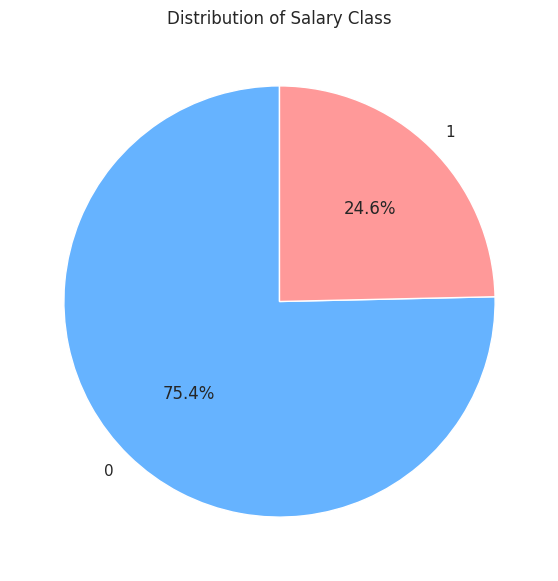

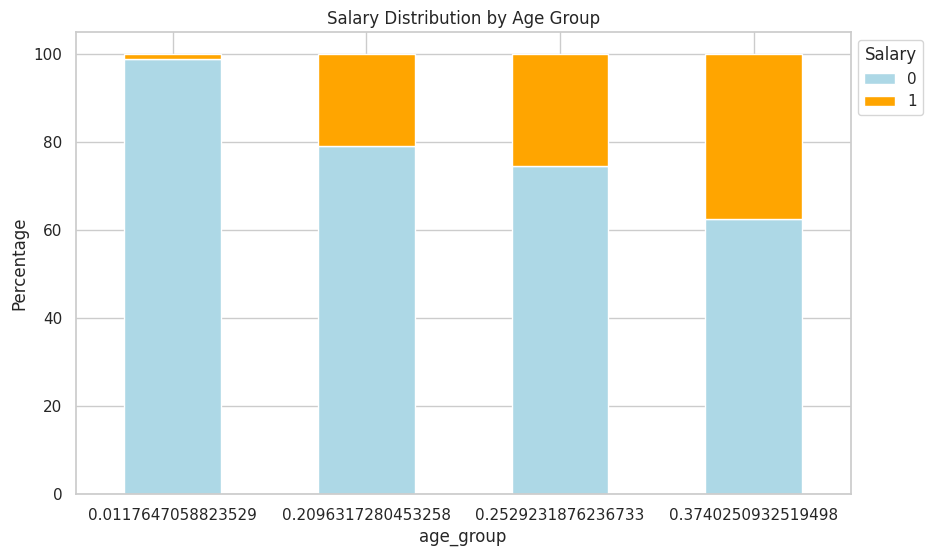

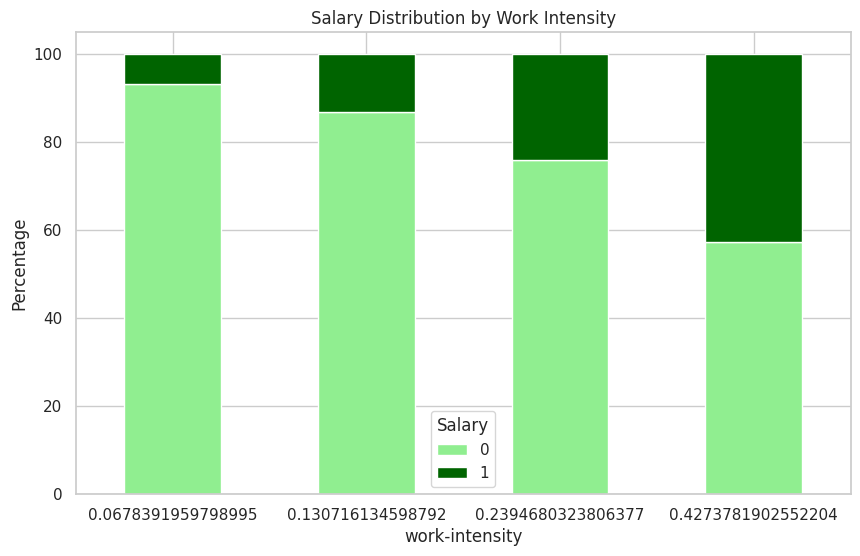

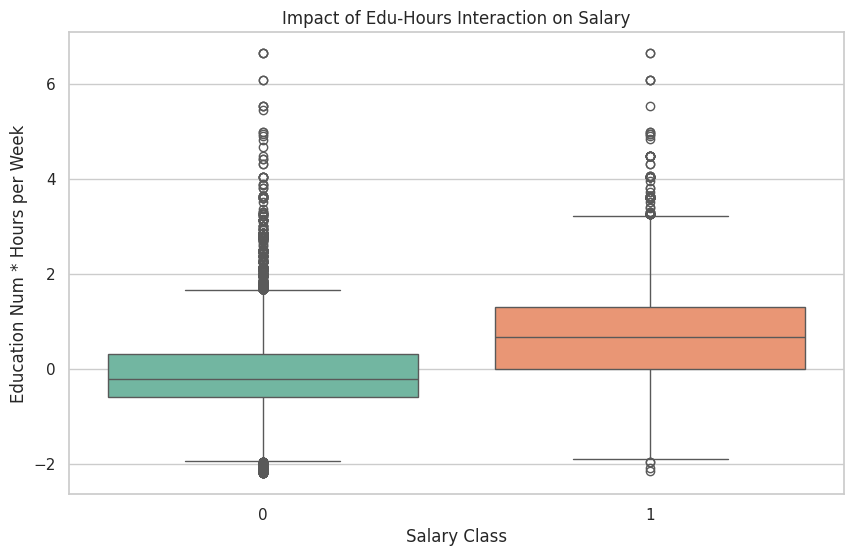

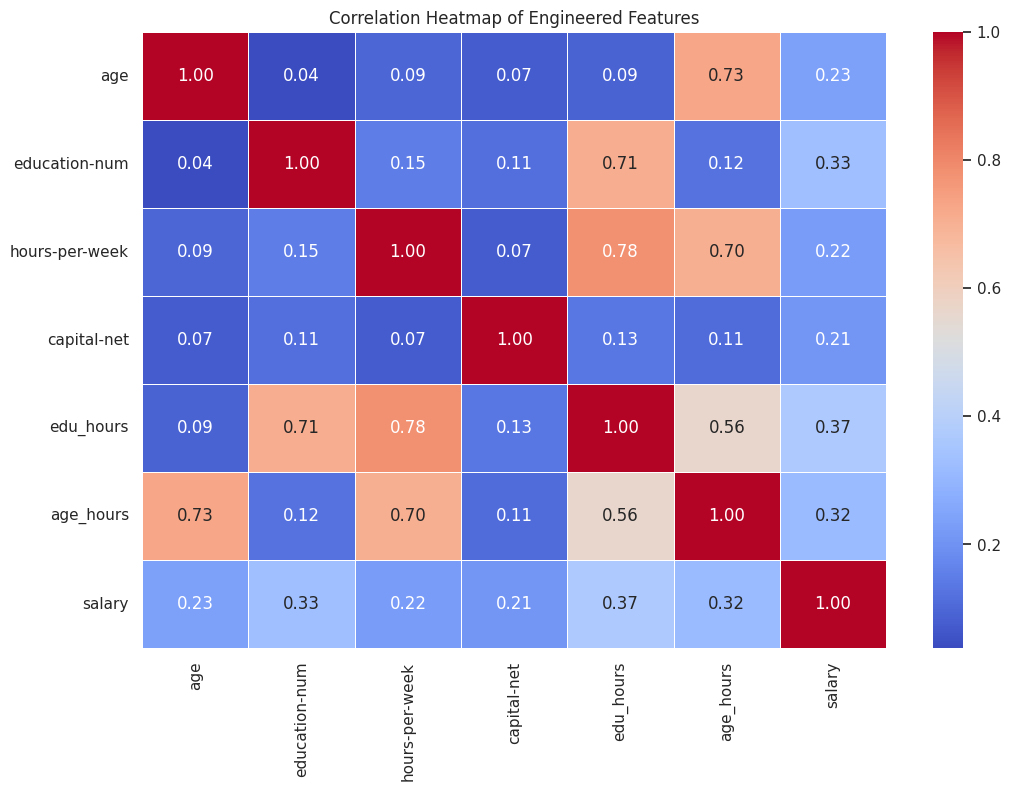

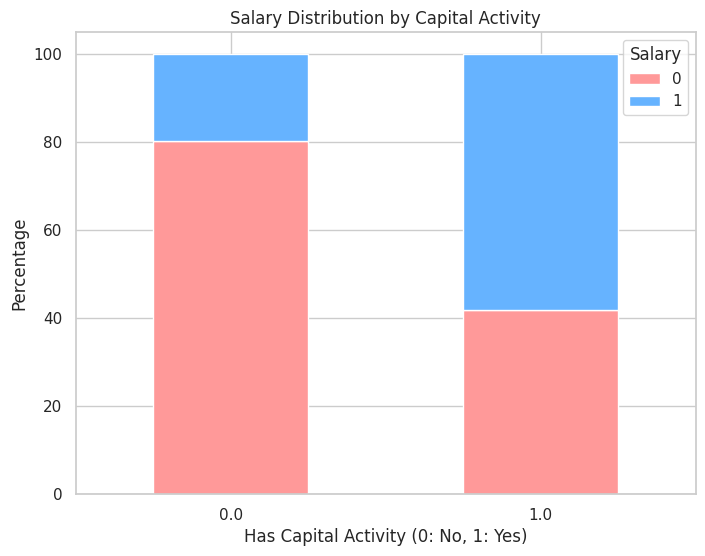

In [18]:
df_train = pd.read_csv('train_processed_v2.csv')

sns.set(style="whitegrid")

# (Pie Chart)
plt.figure(figsize=(7, 7))
df_train['salary'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Distribution of Salary Class')
plt.ylabel('')
plt.show()

#(Stacked Bar)
plt.figure(figsize=(10, 6))
age_sal = pd.crosstab(df_train['age_group'], df_train['salary'], normalize='index') * 100
age_sal.plot(kind='bar', stacked=True, color=['#add8e6', '#ffa500'], ax=plt.gca())
plt.title('Salary Distribution by Age Group')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Salary', bbox_to_anchor=(1, 1))
plt.show()

# (Work Intensity)
plt.figure(figsize=(10, 6))
work_sal = pd.crosstab(df_train['work-intensity'], df_train['salary'], normalize='index') * 100
work_sal.plot(kind='bar', stacked=True, color=['#90ee90', '#006400'], ax=plt.gca())
plt.title('Salary Distribution by Work Intensity')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Salary')
plt.show()

#  (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='salary', y='edu_hours', data=df_train, palette='Set2')
plt.title('Impact of Edu-Hours Interaction on Salary')
plt.xlabel('Salary Class')
plt.ylabel('Education Num * Hours per Week')
plt.show()

# (Correlation Heatmap)
plt.figure(figsize=(12, 8))
num_cols = ['age', 'education-num', 'hours-per-week', 'capital-net', 'edu_hours', 'age_hours', 'salary']

corr = df_train[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Engineered Features')
plt.show()


plt.figure(figsize=(8, 6))
cap_sal = pd.crosstab(df_train['has_capital_activity'], df_train['salary'], normalize='index') * 100
cap_sal.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())
plt.title('Salary Distribution by Capital Activity')
plt.xlabel('Has Capital Activity (0: No, 1: Yes)')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Salary')
plt.show()

## ** Preparing Random Forest Model and solve the problem of unbalanced data **

In [19]:
df = pd.read_csv('train_processed_v2.csv')

# Split features and target
X = df.drop('salary', axis=1)
y = df['salary']

# Applying Cross Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}")
print(f"Resampled training set shape: {X_train_res.shape}")
print(f"Original training target distribution:\n{y_train.value_counts()}")
print(f"Resampled training target distribution:\n{y_train_res.value_counts()}")

rf_sm = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500,600],
    'max_depth': [None, 10, 20, 30,40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random_search_rf_sm = RandomizedSearchCV(
    estimator=rf_sm,
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    n_jobs=-1,
    scoring='f1',
    verbose=1,
    random_state=42
)

random_search_rf_sm.fit(X_train_res, y_train_res)

print("\nBest Parameters (RandomForest with SMOTE):", random_search_rf_sm.best_params_)
print("Best CV F1 Score (RandomForest with SMOTE):", random_search_rf_sm.best_score_)

best_model_rf_sm = random_search_rf_sm.best_estimator_
y_pred_rf_sm = best_model_rf_sm.predict(X_val)


print("\nValidation Set Performance (RandomForest with SMOTE):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf_sm):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_rf_sm):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_rf_sm))


joblib.dump(best_model_rf_sm, 'best_model_rf_smote.joblib')
print("\nBest RandomForest model with SMOTE saved to best_model_rf_smote.joblib")

Original training set shape: (16897, 34)
Resampled training set shape: (25464, 34)
Original training target distribution:
salary
0    12732
1     4165
Name: count, dtype: int64
Resampled training target distribution:
salary
0    12732
1    12732
Name: count, dtype: int64
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best Parameters (RandomForest with SMOTE): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best CV F1 Score (RandomForest with SMOTE): 0.8814752931901193

Validation Set Performance (RandomForest with SMOTE):
Accuracy: 0.8388
F1 Score: 0.6912

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.87      0.89      3184
           1       0.65      0.73      0.69      1041

    accuracy                           0.84      4225
   macro avg       0.78      0.80      0.79      4225
weighted avg       0.85      0.84      0.84      4225


Best Ran

## Use test file (Random Forest Model)


Test Set Performance Evaluation (RandomForest):
Accuracy: 0.8471069808607147
F1 Score: 0.7151690024732069

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.88      0.90      6737
           1       0.68      0.75      0.72      2302

    accuracy                           0.85      9039
   macro avg       0.80      0.82      0.81      9039
weighted avg       0.85      0.85      0.85      9039


Confusion matrix saved to test_confusion_matrix_rf.png

Predictions saved to test_predictions_rf.csv


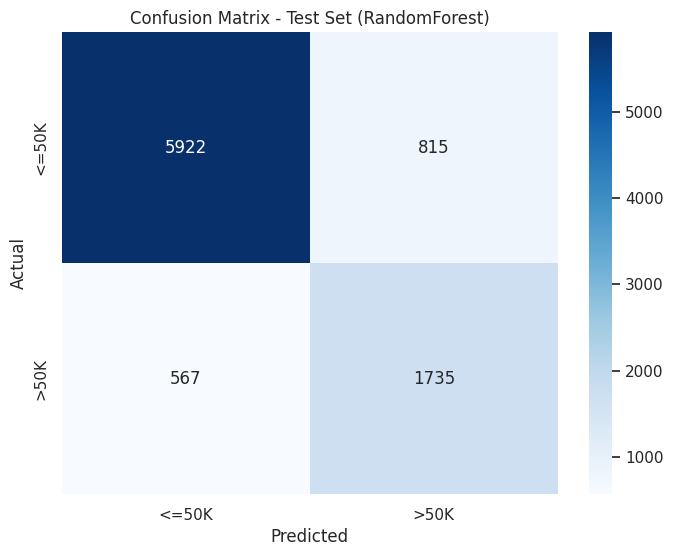

In [20]:
best_rf_model = joblib.load("best_model_rf_smote.joblib")

target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")

# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")


if __name__ == "__main__":
    try:
        df_test_rf = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()

    df_test_rf.rename(columns={ 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)

    # from __main__ import fill_missing_values
    # df_test_rf, _ = fill_missing_values(df_test_rf.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_rf, _ = fill_missing_values(df_test_rf.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)

    # Apply drop_duplicates() to the main test DataFrame before feature engineering
    df_test_rf = df_test_rf.drop_duplicates()
    df_test_rf = df_test_rf.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_rf = df_test_rf.dropna()
    # df_test_rf['native-country'].fillna(df_test_rf['native-country'].mode()[0], inplace=True)


    from __main__ import engineer_features
    df_test_processed_rf = engineer_features(df_test_rf.copy(), is_train=False, encoders=target_encoder, scaler=scaler)
    # Removed redundant df_test_processed_rf.drop_duplicates() as it's now handled on df_test_rf

    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns


    missing_cols_in_test = set(train_cols) - set(df_test_processed_rf.columns)
    for col in missing_cols_in_test:
        df_test_processed_rf[col] = 0
    df_test_processed_rf = df_test_processed_rf[train_cols]

    predictions_rf = best_rf_model.predict(df_test_processed_rf)
    probabilities_rf = best_rf_model.predict_proba(df_test_processed_rf)[:, 1]

    df_test_rf["predicted_salary"] = np.where(predictions_rf == 1, ">50K", "<=50K")
    df_test_rf["prediction_probability_>50K"] = probabilities_rf


    if "salary" in df_test_rf.columns:

        df_test_rf["salary_true"] = df_test_rf["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (RandomForest):")
        print("Accuracy:", accuracy_score(df_test_rf["salary_true"], predictions_rf))
        print("F1 Score:", f1_score(df_test_rf["salary_true"], predictions_rf))
        print("\nClassification Report:\n", classification_report(df_test_rf["salary_true"], predictions_rf))

        cm_rf = confusion_matrix(df_test_rf["salary_true"], predictions_rf)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (RandomForest)')
        plt.savefig('test_confusion_matrix_rf.png')
        print("\nConfusion matrix saved to test_confusion_matrix_rf.png")

    df_test_rf.to_csv("test_predictions_rf.csv", index=False)
    print("\nPredictions saved to test_predictions_rf.csv")

## **XGBClassifier**

In [ ]:



xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

param_dist = {
    'n_estimators': [100, 300,400, 500],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)


random_search.fit(X_train, y_train)
best_model_xgb_sm = random_search.best_estimator_
y_pred_xgb_sm = best_model_xgb_sm.predict(X_val)

print(f"\nBest Training Accuracy (CV): {random_search.best_score_:.4f}")
print(f"Best Params: {random_search.best_params_}")


print("\nValidation Set Performance (XGBoost with SMOTE):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb_sm):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_xgb_sm):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_xgb_sm))

joblib.dump(best_model_xgb_sm, 'best_xgb_model_smote.joblib')
print("\nBest XGBoost model saved successfully!")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Training Accuracy (CV): 0.8667
Best Params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}

Validation Set Performance (XGBoost with SMOTE):
Accuracy: 0.8667
F1 Score: 0.7063

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      3184
           1       0.77      0.65      0.71      1041

    accuracy                           0.87      4225
   macro avg       0.83      0.79      0.81      4225
weighted avg       0.86      0.87      0.86      4225


Best XGBoost model saved successfully!


## use the test file with xgbclassifier


Test Set Performance Evaluation (XGBoost):
Accuracy: 0.8669100564221706
F1 Score: 0.7167412291028962

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91      6737
           1       0.78      0.66      0.72      2302

    accuracy                           0.87      9039
   macro avg       0.84      0.80      0.81      9039
weighted avg       0.86      0.87      0.86      9039


Confusion matrix saved to test_confusion_matrix_xgb.png

Predictions saved to test_predictions_xgb.csv


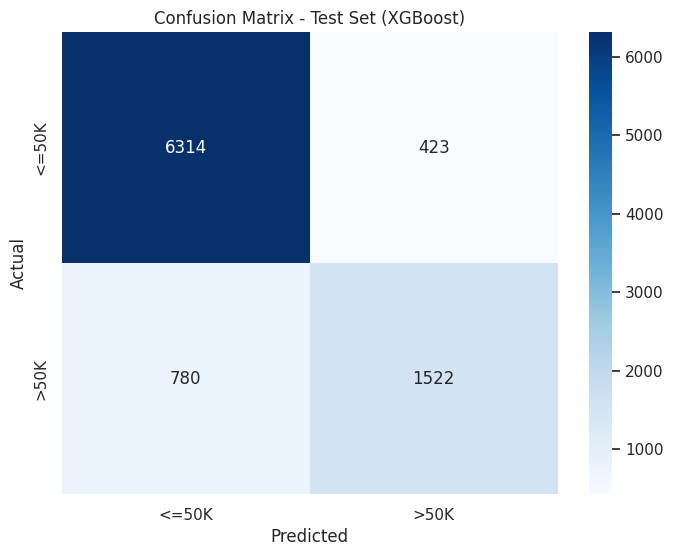

In [22]:
best_xgb_model = joblib.load("best_xgb_model_smote.joblib")

target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")

# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")


if __name__ == "__main__":
    try:
        df_test_xgb = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()


    df_test_xgb.rename(columns={'fnlwgt': 'work-fnl', 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)


    # from __main__ import fill_missing_values
    # df_test_xgb, _ = fill_missing_values(df_test_xgb.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_xgb, _ = fill_missing_values(df_test_xgb.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)
    df_test_xgb = df_test_xgb.drop_duplicates() # Keep drop_duplicates
    df_test_xgb = df_test_xgb.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_xgb = df_test_xgb.dropna()
    # df_test_xgb['native-country'].fillna(df_test_xgb['native-country'].mode()[0], inplace=True)
    # Removed df_test_xgb.dropna()
    from __main__ import engineer_features
    df_test_processed_xgb = engineer_features(df_test_xgb.copy(), is_train=False, encoders=target_encoder, scaler=scaler)


    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns


    missing_cols_in_test = set(train_cols) - set(df_test_processed_xgb.columns)
    for col in missing_cols_in_test:
        df_test_processed_xgb[col] = 0
    df_test_processed_xgb = df_test_processed_xgb[train_cols]


    predictions_xgb = best_xgb_model.predict(df_test_processed_xgb)
    probabilities_xgb = best_xgb_model.predict_proba(df_test_processed_xgb)[:, 1]


    df_test_xgb["predicted_salary"] = np.where(predictions_xgb == 1, ">50K", "<=50K")
    df_test_xgb["prediction_probability_>50K"] = probabilities_xgb


    if "salary" in df_test_xgb.columns:
        df_test_xgb["salary_true"] = df_test_xgb["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (XGBoost):")
        print("Accuracy:", accuracy_score(df_test_xgb["salary_true"], predictions_xgb))
        print("F1 Score:", f1_score(df_test_xgb["salary_true"], predictions_xgb))
        print("\nClassification Report:\n", classification_report(df_test_xgb["salary_true"], predictions_xgb))

        # Confusion Matrix
        cm_xgb = confusion_matrix(df_test_xgb["salary_true"], predictions_xgb)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (XGBoost)')
        plt.savefig('test_confusion_matrix_xgb.png')
        print("\nConfusion matrix saved to test_confusion_matrix_xgb.png")

    df_test_xgb.to_csv("test_predictions_xgb.csv", index=False)
    print("\nPredictions saved to test_predictions_xgb.csv")

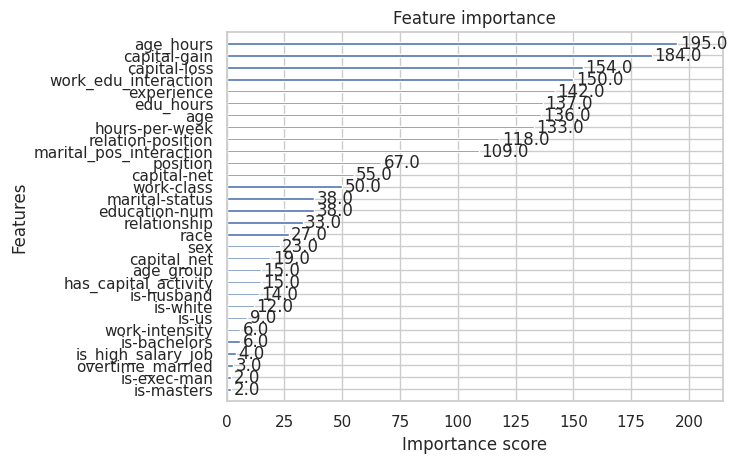

In [23]:

xgb.plot_importance(best_model_xgb_sm, max_num_features=30)
plt.show()

In [24]:
results = {
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(df_test_rf["salary_true"], predictions_rf),accuracy_score(df_test_xgb["salary_true"], predictions_xgb)],
    'F1-Score': [f1_score(df_test_rf["salary_true"], predictions_rf),  f1_score(df_test_xgb["salary_true"], predictions_xgb)]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

           Model  Accuracy  F1-Score
0  Random Forest  0.847107  0.715169
1        XGBoost  0.866910  0.716741


## Logistic Regression


In [25]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(
    random_state=42,
    solver='liblinear',
    class_weight='balanced'
)

param_dist_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 200, 300]
}

random_search_lr = RandomizedSearchCV(
    estimator=lr_clf,
    param_distributions=param_dist_lr,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_lr.fit(X_train, y_train)

best_model_lr_sm = random_search_lr.best_estimator_
y_pred_lr_sm = best_model_lr_sm.predict(X_val)

print(f"\nBest CV F1 Score (Logistic Regression with SMOTE): {random_search_lr.best_score_:.4f}")
print(f"Best Parameters (Logistic Regression with SMOTE): {random_search_lr.best_params_}")

print("\nValidation Set Performance (Logistic Regression with SMOTE):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr_sm):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_lr_sm):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_lr_sm))

joblib.dump(best_model_lr_sm, 'best_lr_model_smote.joblib')
print("\nBest Logistic Regression model saved to best_lr_model_smote.joblib")

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best CV F1 Score (Logistic Regression with SMOTE): 0.6847
Best Parameters (Logistic Regression with SMOTE): {'penalty': 'l1', 'max_iter': 200, 'C': 10}

Validation Set Performance (Logistic Regression with SMOTE):
Accuracy: 0.8149
F1 Score: 0.6899

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87      3184
           1       0.59      0.84      0.69      1041

    accuracy                           0.81      4225
   macro avg       0.76      0.82      0.78      4225
weighted avg       0.85      0.81      0.82      4225


Best Logistic Regression model saved to best_lr_model_smote.joblib


## Use test file with Logistic Regression


Test Set Performance Evaluation (Logistic Regression):
Accuracy: 0.8170151565438655
F1 Score: 0.7003623188405798

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.81      0.87      6737
           1       0.60      0.84      0.70      2302

    accuracy                           0.82      9039
   macro avg       0.77      0.82      0.78      9039
weighted avg       0.85      0.82      0.83      9039


Confusion matrix saved to test_confusion_matrix_lr.png

Predictions saved to test_predictions_lr.csv


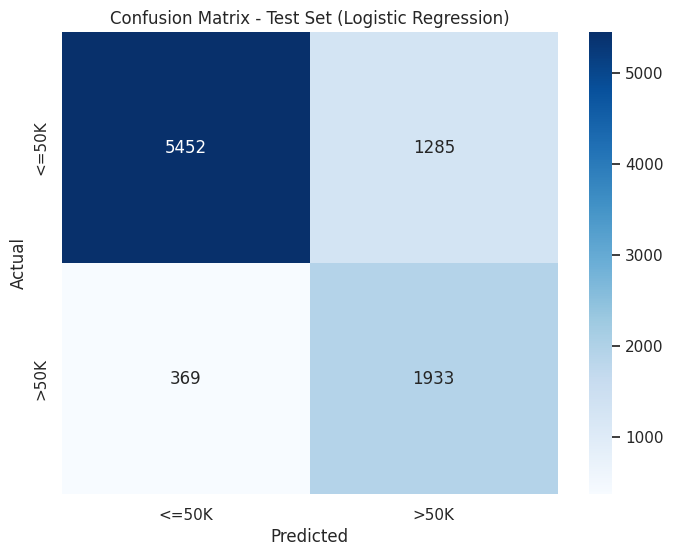

In [26]:
import joblib

best_lr_model = joblib.load("best_lr_model_smote.joblib")

target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")

# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")


if __name__ == "__main__":
    try:
        df_test_lr = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()


    df_test_lr.rename(columns={'fnlwgt': 'work-fnl', 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)


    # from __main__ import fill_missing_values
    # df_test_lr, _ = fill_missing_values(df_test_lr.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_lr, _ = fill_missing_values(df_test_lr.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)
    df_test_lr = df_test_lr.drop_duplicates() # Keep drop_duplicates
    df_test_lr = df_test_lr.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_lr = df_test_lr.dropna()
    # df_test_lr['native-country'].fillna(df_test_lr['native-country'].mode()[0], inplace=True)

    from __main__ import engineer_features
    df_test_processed_lr = engineer_features(df_test_lr.copy(), is_train=False, encoders=target_encoder, scaler=scaler)


    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns


    missing_cols_in_test = set(train_cols) - set(df_test_processed_lr.columns)
    for col in missing_cols_in_test:
        df_test_processed_lr[col] = 0
    df_test_processed_lr = df_test_processed_lr[train_cols]


    predictions_lr = best_lr_model.predict(df_test_processed_lr)
    probabilities_lr = best_lr_model.predict_proba(df_test_processed_lr)[:, 1]


    df_test_lr["predicted_salary"] = np.where(predictions_lr == 1, ">50K", "<=50K")
    df_test_lr["prediction_probability_>50K"] = probabilities_lr


    if "salary" in df_test_lr.columns:
        df_test_lr["salary_true"] = df_test_lr["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (Logistic Regression):")
        print("Accuracy:", accuracy_score(df_test_lr["salary_true"], predictions_lr))
        print("F1 Score:", f1_score(df_test_lr["salary_true"], predictions_lr))
        print("\nClassification Report:\n", classification_report(df_test_lr["salary_true"], predictions_lr))

        # Confusion Matrix
        cm_lr = confusion_matrix(df_test_lr["salary_true"], predictions_lr)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (Logistic Regression)')
        plt.savefig('test_confusion_matrix_lr.png')
        print("\nConfusion matrix saved to test_confusion_matrix_lr.png")

    df_test_lr.to_csv("test_predictions_lr.csv", index=False)
    print("\nPredictions saved to test_predictions_lr.csv")

## SVM

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train,
    train_size=100,
    stratify=y_train,
    random_state=42
)

print(f"Sample size for tuning: {X_sample.shape[0]} rows")

svm_clf = SVC(
    random_state=42,
    class_weight='balanced',
    probability=True # Added to enable predict_proba
)

param_dist_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.1, 0.01],
    'degree': [2, 3]
}

random_search_svm = RandomizedSearchCV(
    estimator=svm_clf,
    param_distributions=param_dist_svm,
    n_iter=10,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("Starting SVM Hyperparameter Tuning on Sample... This will be fast!")
random_search_svm.fit(X_sample, y_sample)

print(f"\nBest Parameters found: {random_search_svm.best_params_}")

best_svm_model = random_search_svm.best_estimator_

print("\nTraining the BEST SVM model on the FULL dataset (This will take a few minutes)...")
best_svm_model.fit(X_train, y_train)

y_pred_svm = best_svm_model.predict(X_val)

print("\nValidation Set Performance (SVM on Full Data):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_svm):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_svm))

joblib.dump(best_svm_model, 'best_svm_model.joblib')
print("\nBest SVM model saved to best_svm_model.joblib")

Sample size for tuning: 100 rows
Starting SVM Hyperparameter Tuning on Sample... This will be fast!
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters found: {'kernel': 'rbf', 'gamma': 'auto', 'degree': 3, 'C': 1}

Training the BEST SVM model on the FULL dataset (This will take a few minutes)...

Validation Set Performance (SVM on Full Data):
Accuracy: 0.8140
F1 Score: 0.6970

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87      3184
           1       0.58      0.87      0.70      1041

    accuracy                           0.81      4225
   macro avg       0.77      0.83      0.78      4225
weighted avg       0.86      0.81      0.82      4225


Best SVM model saved to best_svm_model.joblib


## use the test file with SVM


Test Set Performance Evaluation (SVM):
Accuracy: 0.8221042150680385
F1 Score: 0.7153982300884956

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87      6737
           1       0.60      0.88      0.72      2302

    accuracy                           0.82      9039
   macro avg       0.78      0.84      0.79      9039
weighted avg       0.86      0.82      0.83      9039


Confusion matrix saved to test_confusion_matrix_svm.png

Predictions saved to test_predictions_svm.csv


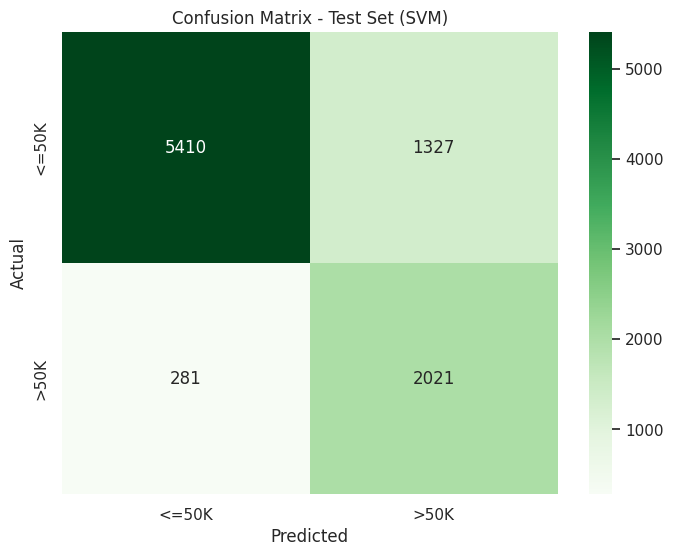

In [28]:
import joblib

best_svm_model = joblib.load("best_svm_model.joblib")

target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")
# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")


if __name__ == "__main__":
    try:
        df_test_svm = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()

    df_test_svm.rename(columns={'fnlwgt': 'work-fnl', 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)

    # from __main__ import fill_missing_values
    # df_test_svm, _ = fill_missing_values(df_test_svm.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_svm, _ = fill_missing_values(df_test_svm.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)

    df_test_svm = df_test_svm.drop_duplicates() # This line should be kept, it's not related to missing values
    df_test_svm = df_test_svm.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_svm = df_test_svm.dropna()
    # df_test_svm['native-country'].fillna(df_test_svm['native-country'].mode()[0], inplace=True)

    from __main__ import engineer_features
    df_test_processed_svm = engineer_features(df_test_svm.copy(), is_train=False, encoders=target_encoder, scaler=scaler)

    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns

    missing_cols_in_test = set(train_cols) - set(df_test_processed_svm.columns)
    for col in missing_cols_in_test:
        df_test_processed_svm[col] = 0
    df_test_processed_svm = df_test_processed_svm[train_cols]

    predictions_svm = best_svm_model.predict(df_test_processed_svm)
    df_test_svm["predicted_salary"] = np.where(predictions_svm == 1, ">50K", "<=50K")

    try:
        probabilities_svm = best_svm_model.predict_proba(df_test_processed_svm)[:, 1]
        df_test_svm["prediction_probability_>50K"] = probabilities_svm
    except AttributeError:
        df_test_svm["decision_score"] = best_svm_model.decision_function(df_test_processed_svm)

    if "salary" in df_test_svm.columns:
        df_test_svm["salary_true"] = df_test_svm["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (SVM):")
        print("Accuracy:", accuracy_score(df_test_svm["salary_true"], predictions_svm))
        print("F1 Score:", f1_score(df_test_svm["salary_true"], predictions_svm))
        print("\nClassification Report:\n", classification_report(df_test_svm["salary_true"], predictions_svm))

        cm_svm = confusion_matrix(df_test_svm["salary_true"], predictions_svm)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (SVM)')
        plt.savefig('test_confusion_matrix_svm.png')
        print("\nConfusion matrix saved to test_confusion_matrix_svm.png")

    df_test_svm.to_csv("test_predictions_svm.csv", index=False)
    print("\nPredictions saved to test_predictions_svm.csv")

## Decision Tree  

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

dt_clf = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

param_dist_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20, 30],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2']
}

random_search_dt = RandomizedSearchCV(
    estimator=dt_clf,
    param_distributions=param_dist_dt,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting Decision Tree Hyperparameter Tuning...")
random_search_dt.fit(X_train, y_train)

best_model_dt = random_search_dt.best_estimator_
y_pred_dt = best_model_dt.predict(X_val)

print(f"\nBest CV F1 Score (Decision Tree): {random_search_dt.best_score_:.4f}")
print(f"Best Parameters (Decision Tree): {random_search_dt.best_params_}")

print("\nValidation Set Performance (Decision Tree):")
print(f"Accuracy: {accuracy_score(y_val, y_pred_dt):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_dt))

joblib.dump(best_model_dt, 'best_dt_model.joblib')
print("\nBest Decision Tree model saved to best_dt_model.joblib")

Starting Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1 Score (Decision Tree): 0.6769
Best Parameters (Decision Tree): {'min_samples_split': 2, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 10, 'criterion': 'gini'}

Validation Set Performance (Decision Tree):
Accuracy: 0.8047
F1 Score: 0.6746

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86      3184
           1       0.57      0.82      0.67      1041

    accuracy                           0.80      4225
   macro avg       0.75      0.81      0.77      4225
weighted avg       0.84      0.80      0.81      4225


Best Decision Tree model saved to best_dt_model.joblib


## use the test file with Decision Tree


Test Set Performance Evaluation (Decision Tree):
Accuracy: 0.808496515101228
F1 Score: 0.6903952781255589

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.80      0.86      6737
           1       0.59      0.84      0.69      2302

    accuracy                           0.81      9039
   macro avg       0.76      0.82      0.78      9039
weighted avg       0.85      0.81      0.82      9039


Confusion matrix saved to test_confusion_matrix_dt.png

Predictions saved to test_predictions_dt.csv


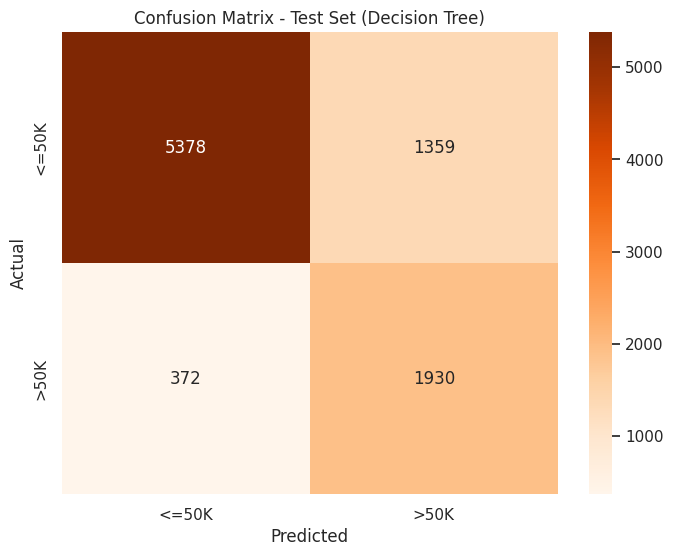

In [30]:
import joblib

best_dt_model = joblib.load("best_dt_model.joblib")

# These need to be loaded for engineer_features as well
target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")
# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")

if __name__ == "__main__":
    try:
        df_test_dt = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()

    df_test_dt.rename(columns={'fnlwgt': 'work-fnl', 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)

    # from __main__ import fill_missing_values
    # df_test_dt, _ = fill_missing_values(df_test_dt.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_dt, _ = fill_missing_values(df_test_dt.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)

    # df_test_dt.dropna() # Removed redundant dropna()
    df_test_dt = df_test_dt.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_dt = df_test_dt.dropna()
    df_test_dt = df_test_dt.drop_duplicates() # Keep drop_duplicates
    # df_test_dt['native-country'].fillna(df_test_dt['native-country'].mode()[0], inplace=True)

    from __main__ import engineer_features
    df_test_processed_dt = engineer_features(df_test_dt.copy(), is_train=False, encoders=target_encoder, scaler=scaler)

    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns

    missing_cols_in_test = set(train_cols) - set(df_test_processed_dt.columns)
    for col in missing_cols_in_test:
        df_test_processed_dt[col] = 0
    df_test_processed_dt = df_test_processed_dt[train_cols]

    predictions_dt = best_dt_model.predict(df_test_processed_dt)
    probabilities_dt = best_dt_model.predict_proba(df_test_processed_dt)[:, 1]

    df_test_dt["predicted_salary"] = np.where(predictions_dt == 1, ">50K", "<=50K")
    df_test_dt["prediction_probability_>50K"] = probabilities_dt

    if "salary" in df_test_dt.columns:
        df_test_dt["salary_true"] = df_test_dt["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (Decision Tree):")
        print("Accuracy:", accuracy_score(df_test_dt["salary_true"], predictions_dt))
        print("F1 Score:", f1_score(df_test_dt["salary_true"], predictions_dt))
        print("\nClassification Report:\n", classification_report(df_test_dt["salary_true"], predictions_dt))

        cm_dt = confusion_matrix(df_test_dt["salary_true"], predictions_dt)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (Decision Tree)')
        plt.savefig('test_confusion_matrix_dt.png')
        print("\nConfusion matrix saved to test_confusion_matrix_dt.png")

    df_test_dt.to_csv("test_predictions_dt.csv", index=False)
    print("\nPredictions saved to test_predictions_dt.csv")

## Stacking Classifier

In [31]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

base_models =[
     ('rf', best_model_rf_sm),
     ('xgb', best_xgb_model),
     ('lr', best_model_lr_sm),
     ('svm',best_svm_model),
     ('dt',best_dt_model)
 ]

meta_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(solver='liblinear', random_state=42, C=10),
    cv=5,
    n_jobs=-1
)

meta_model.fit(X_train, y_train)
y_pred_stacked = meta_model.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred_stacked):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_stacked):.4f}")
print("\nClassification Report:\n", classification_report(y_val, y_pred_stacked))

joblib.dump(meta_model, 'meta_stacked_model.joblib')
print("\nBest meta_stacked_model model saved successfully!")

Accuracy: 0.8656
F1 Score: 0.7081

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91      3184
           1       0.76      0.66      0.71      1041

    accuracy                           0.87      4225
   macro avg       0.83      0.80      0.81      4225
weighted avg       0.86      0.87      0.86      4225


Best meta_stacked_model model saved successfully!



Test Set Performance Evaluation (Meta):
Accuracy: 0.8691226905631154
F1 Score: 0.7264739884393063

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91      6737
           1       0.78      0.68      0.73      2302

    accuracy                           0.87      9039
   macro avg       0.84      0.81      0.82      9039
weighted avg       0.87      0.87      0.87      9039


Confusion matrix saved to test_confusion_matrix_met.png

Predictions saved to test_predictions_met.csv


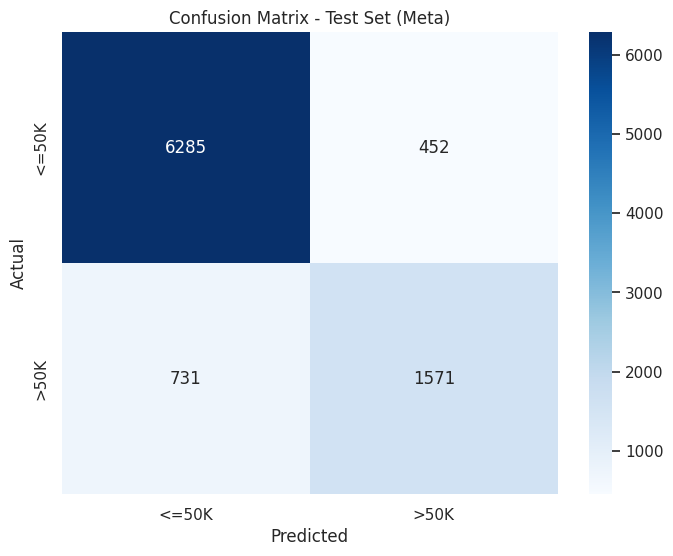

In [32]:
best_meta_model = joblib.load("meta_stacked_model.joblib")

target_encoder = joblib.load("target_encoder.joblib")
scaler = joblib.load("scaler_v2.joblib")

# model_workclass_imputer = joblib.load("model_workclass_train.joblib")
# model_position_imputer = joblib.load("model_position_train.joblib")


if __name__ == "__main__":
    try:
        df_test_met = pd.read_csv("Test.csv")
    except FileNotFoundError:
        print("Test.csv not found.")
        exit()


    df_test_met.rename(columns={'fnlwgt': 'work-fnl', 'workclass': 'work-class', 'occupation': 'position'}, inplace=True)


    # from __main__ import fill_missing_values
    # df_test_met, _ = fill_missing_values(df_test_met.copy(), target_col='work-class', drop_cols=['salary', 'position'], model=model_workclass_imputer)
    # df_test_met, _ = fill_missing_values(df_test_met.copy(), target_col='position', drop_cols=['salary'], model=model_position_imputer)
    df_test_met = df_test_met.drop_duplicates() # Added drop_duplicates
    df_test_met = df_test_met.replace(r'^\s*\?\s*$', np.nan, regex=True)
    df_test_met = df_test_met.dropna()
    # df_test_met['native-country'].fillna(df_test_met['native-country'].mode()[0], inplace=True)

    from __main__ import engineer_features
    df_test_processed_met = engineer_features(df_test_met.copy(), is_train=False, encoders=target_encoder, scaler=scaler)


    train_df = pd.read_csv("train_processed_v2.csv")
    train_cols = train_df.drop("salary", axis=1).columns


    missing_cols_in_test = set(train_cols) - set(df_test_processed_met.columns)
    for col in missing_cols_in_test:
        df_test_processed_met[col] = 0
    df_test_processed_met = df_test_processed_met[train_cols]


    predictions_met = best_meta_model.predict(df_test_processed_met)
    probabilities_met = best_meta_model.predict_proba(df_test_processed_met)[:, 1]


    df_test_met["predicted_salary"] = np.where(predictions_met == 1, ">50K", "<=50K")
    df_test_met["prediction_probability_>50K"] = probabilities_met


    if "salary" in df_test_met.columns:
        df_test_met["salary_true"] = df_test_met["salary"].astype(str).str.strip().apply(lambda x: 1 if x == ">50K" else 0)

        print("\nTest Set Performance Evaluation (Meta):")
        print("Accuracy:", accuracy_score(df_test_met["salary_true"], predictions_met))
        print("F1 Score:", f1_score(df_test_met["salary_true"], predictions_met))
        print("\nClassification Report:\n", classification_report(df_test_met["salary_true"], predictions_met))

        # Confusion Matrix
        cm_xgb = confusion_matrix(df_test_met["salary_true"], predictions_met)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix - Test Set (Meta)')
        plt.savefig('test_confusion_matrix_met.png')
        print("\nConfusion matrix saved to test_confusion_matrix_met.png")

    df_test_xgb.to_csv("test_predictions_met.csv", index=False)
    print("\nPredictions saved to test_predictions_met.csv")

In [33]:
results = {
    'Model': ['Random Forest', 'XGBoost', 'Logistic Regression','SVM','Decision Tree', 'Stacked (RF+XGB+LR, Meta=LR)'],
    'Accuracy': [
        accuracy_score(df_test_rf["salary_true"], predictions_rf),
        accuracy_score(df_test_xgb["salary_true"], predictions_xgb),
        accuracy_score(df_test_lr["salary_true"], predictions_lr),
        accuracy_score(df_test_svm['salary_true'],predictions_svm),
        accuracy_score(df_test_dt['salary_true'],predictions_dt),
        accuracy_score(df_test_met["salary_true"], predictions_met)
    ],
    'F1-Score': [
        f1_score(df_test_rf["salary_true"], predictions_rf),
        f1_score(df_test_xgb["salary_true"], predictions_xgb),
        f1_score(df_test_lr["salary_true"], predictions_lr),
        f1_score(df_test_svm["salary_true"], predictions_svm),
        f1_score(df_test_dt["salary_true"], predictions_dt),
        f1_score(df_test_met["salary_true"], predictions_met)
    ]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

                          Model  Accuracy  F1-Score
0                 Random Forest  0.847107  0.715169
1                       XGBoost  0.866910  0.716741
2           Logistic Regression  0.817015  0.700362
3                           SVM  0.822104  0.715398
4                 Decision Tree  0.808497  0.690395
5  Stacked (RF+XGB+LR, Meta=LR)  0.869123  0.726474


In [34]:
#make pkl of model , encoder and scaler
import pickle
pickle.dump(best_xgb_model,open('best_xgb_model.pkl','wb'))
pickle.dump(target_encoder,open('target_encoder.pkl','wb'))
pickle.dump(scaler,open('scaler.pkl','wb'))